In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'us-accidents' dataset.
Path to dataset files: /kaggle/input/us-accidents


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import os

os.listdir("/kaggle/input/us-accidents")

['US_Accidents_March23.csv']

In [9]:
df = pd.read_csv(
    "/kaggle/input/us-accidents/US_Accidents_March23.csv",
    nrows=200000
)

df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [10]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])

df["Hour"] = df["Start_Time"].dt.hour
df["Month"] = df["Start_Time"].dt.month
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek

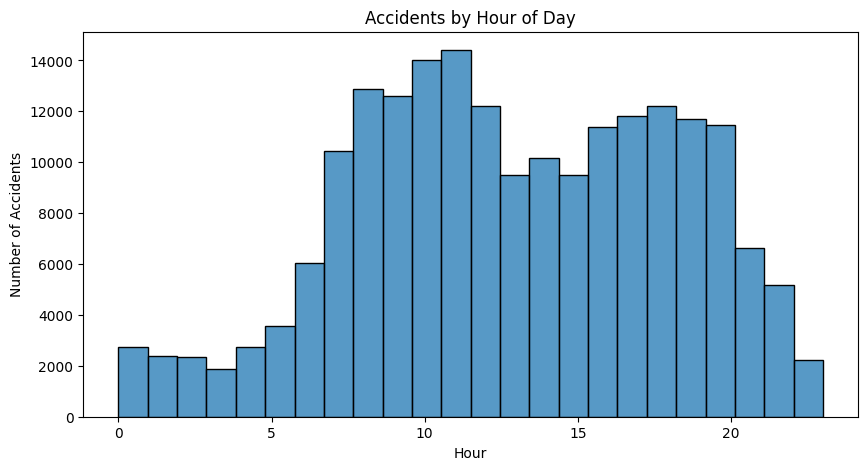

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df["Hour"], bins=24)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")

plt.show()

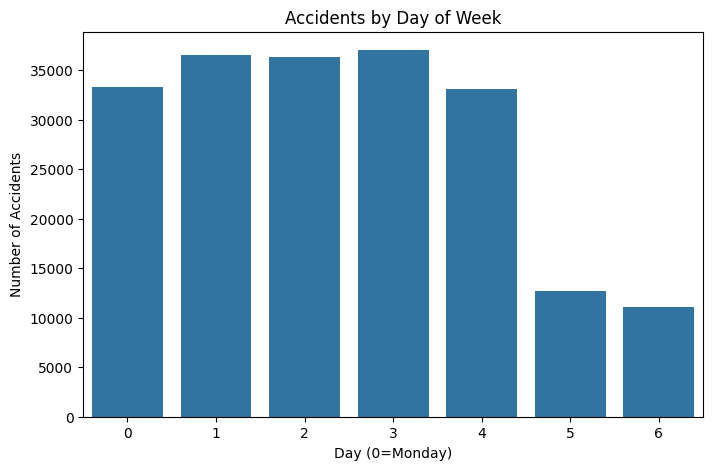

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(x="DayOfWeek", data=df)

plt.title("Accidents by Day of Week")
plt.xlabel("Day (0=Monday)")
plt.ylabel("Number of Accidents")

plt.show()

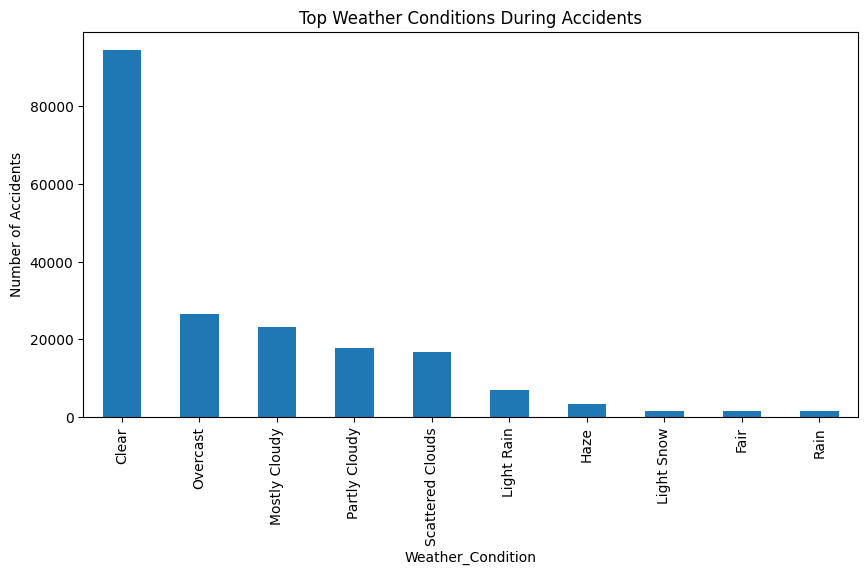

In [13]:
top_weather = df["Weather_Condition"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_weather.plot(kind="bar")

plt.title("Top Weather Conditions During Accidents")
plt.ylabel("Number of Accidents")

plt.show()

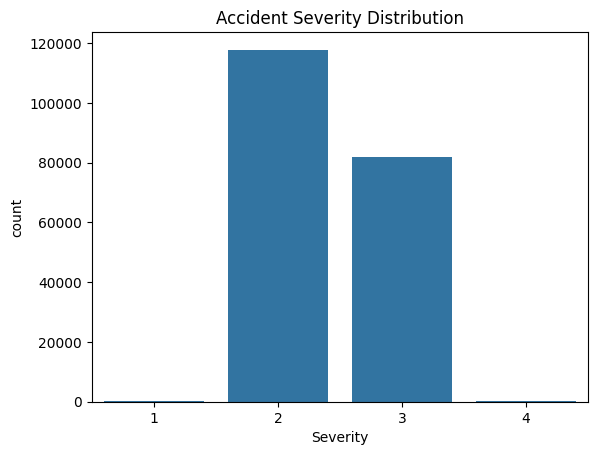

In [14]:
sns.countplot(x="Severity", data=df)

plt.title("Accident Severity Distribution")

plt.show()

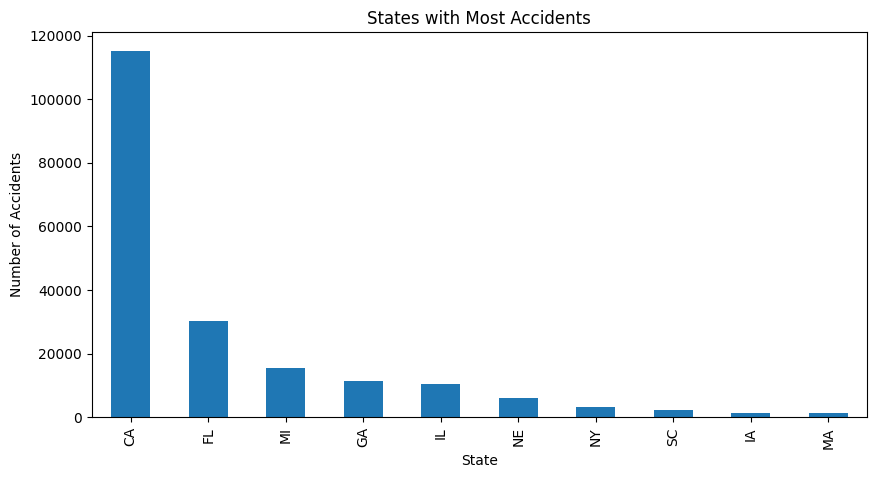

In [15]:
top_states = df["State"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_states.plot(kind="bar")

plt.title("States with Most Accidents")

plt.ylabel("Number of Accidents")

plt.show()

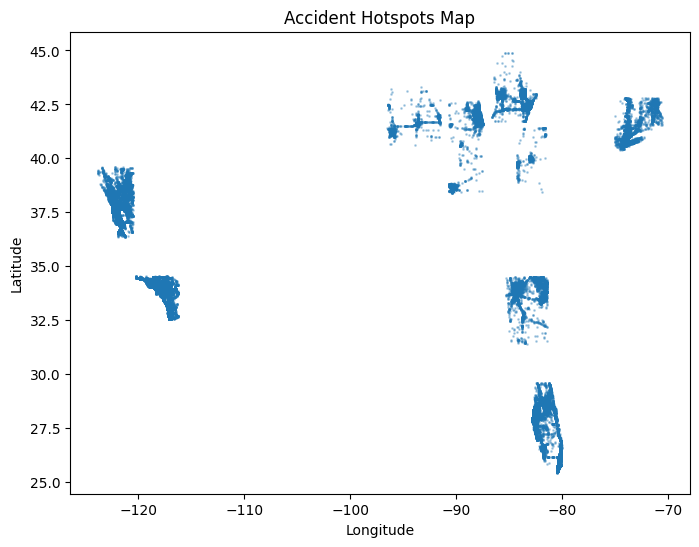

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(df["Start_Lng"], df["Start_Lat"], s=1, alpha=0.3)

plt.title("Accident Hotspots Map")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

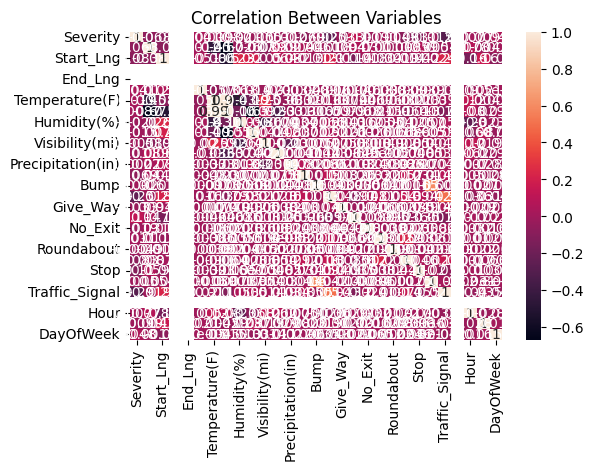

In [17]:
plt.figure(figsize=(6,4))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Between Variables")

plt.show()

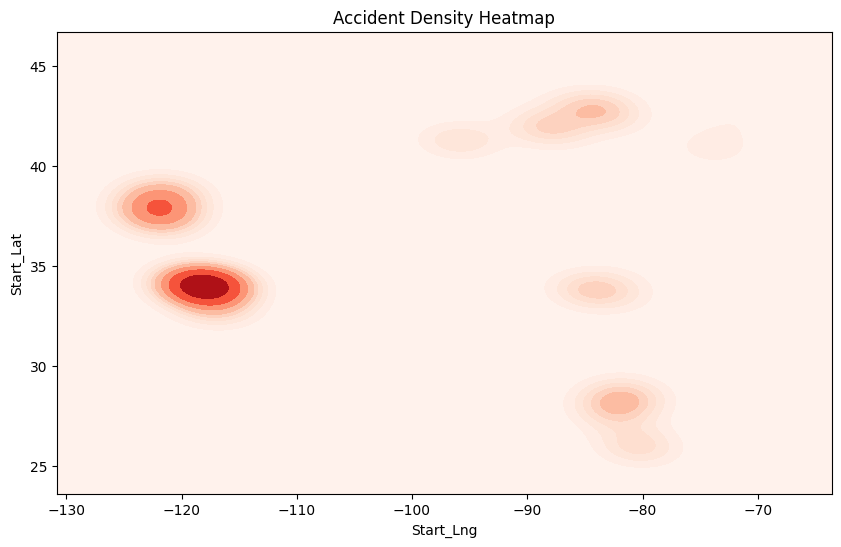

In [18]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    x=df["Start_Lng"],
    y=df["Start_Lat"],
    cmap="Reds",
    fill=True,
    thresh=0
)

plt.title("Accident Density Heatmap")

plt.show()

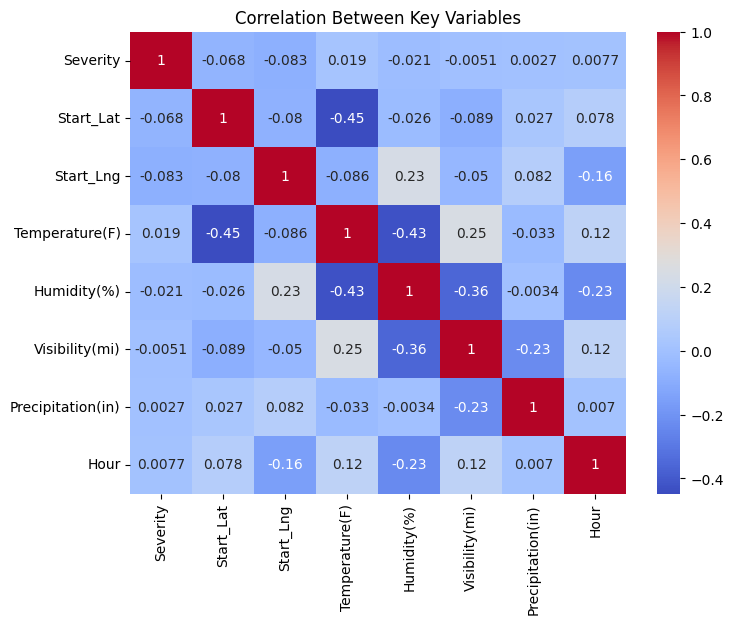

In [19]:
cols = [
    "Severity",
    "Start_Lat",
    "Start_Lng",
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Precipitation(in)",
    "Hour"
]

corr = df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Key Variables")

plt.show()